# Simulating HH for simple drives

**The Hodgkin–Huxley Model is defined by the differential equation**  
![](model_eq.png)  
**in which:**  
![](currents.png)  
**g is conductance, and E is the Nernst potential. The three gating variables m, n, and h evolve according to:**  
![](alpha.png?ver2)  
**In which α and β are the transition rates:**  
![](gating_param.png)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp

**Model Parameters**

Units: $u$ in $mV$, $t$ in $ms$, $C$ in $\mu F/cm^2$, $g$ in $mS/cm^2$, $I$ in $\mu A/cm^2$

In [2]:
C = 1 # μF/cm^2 , membrane capacity

g_Na = 120 # mS/cm^2
g_K = 36 # mS/cm^2
g_L = 0.3 # mS/cm^2

E_Na = 50 # mV
E_K = -77 # mV
E_L = -54.4 # mV

u0 = -65 #mV ==> "initial potential"
t0 = 0
simulation_time = 100 # ms
time_res = 0.1 # ms
t_array = np.arange(0,simulation_time+time_res,time_res)

**Transition Rate Functions**

In [3]:

def alpha_n(u):
    return 0.01*(u+55)/(1-np.exp(-(u+55)/10))

def alpha_m(u):
    return 0.1*(u+40)/(1-np.exp(-(u+40)/10))

def alpha_h(u):
    return 0.07*np.exp(-(u+65)/20)

def beta_n(u):
    return 0.125*np.exp(-(u+65)/80)

def beta_m(u):
    return 4*np.exp(-(u+65)/18)

def beta_h(u):
    return 1/(np.exp(-(u+35)/10)+1)

**For a neuron at rest we have:** 


$0 = \alpha(u_0)\,(1-x_0)-\beta(u_0)\,x_0$  


therefore:  


$x_0 = \frac{\alpha}{\alpha+\beta}$

**Note**: Notation used for the equilibrium function $x_0$ instead of $x_\infty$ is based on Gerstner et al., Neuronal Dynamics (Ch. 2)

In [4]:
m0 = alpha_m(u0)/(alpha_m(u0)+beta_m(u0))
h0 = alpha_h(u0)/(alpha_h(u0)+beta_h(u0))
n0 = alpha_n(u0)/(alpha_n(u0)+beta_n(u0))

Value of the membrane potential at the equilibrium is quite close to $u_0=-65.0 mV$. At this fixed point we should have:  
$$\sum_i {I_i} = g_{Na} m_0^3 h_0 (u_0-E_{Na}) + g_{K} n_0^4 (u_0-E_{K})  + g_{L} (u_0-E_{L}) = 0$$

While in our simulation we get:

In [5]:
print("I(t) at u0 =", round(g_Na*m0**3*h0*(u0-E_Na) + g_K*n0**4*(u0-E_K)  + g_L*(u0-E_L),5), "μA/cm^2")

I(t) at u0 = -0.00032 μA/cm^2


**True Fixed Point:**  
To find the fixed point of the system we can explicitly set $I(t)$ and $\frac{du}{dt}$ to zero and find the voltage at which this condition is met:  
$$\sum_i {I_i} = g_{Na} m_{u_{rest}}^3 h_{u_{rest}} (u_{rest}-E_{Na}) + g_{K} n_{u_{rest}}^4 (u_{rest}-E_{K})  + g_{L} (u_{rest}-E_{L}) = 0$$


In [6]:
def fixed(u):
        return g_Na*(alpha_m(u)/(alpha_m(u)+beta_m(u)))**3*(alpha_h(u)/(alpha_h(u)+beta_h(u)))*\
                (u-E_Na) + g_K*(alpha_n(u)/(alpha_n(u)+beta_n(u)))**4*(u-E_K)  + g_L*(u-E_L)


print("True fixed point for the membrane voltage = ",round(sp.optimize.fsolve(fixed,-65)[0],5), "mV")

True fixed point for the membrane voltage =  -64.99972 mV


This small discrepancy is within the uncertainty of our analysis, therefore -65.0 mV will be used as the true resting potential.

**ODE Function & Solver**

In [7]:

def f(t ,vec , I):
    """Solving the system of differential equations:
    [du/dt,dm/dt,dh/dt,dn/dt] simultaneously.
    """

    du_dt = 1/C*(I(t) - (
                        g_Na*vec[1]**3*vec[2]*(vec[0]-E_Na) +\
                        g_K*vec[3]**4*(vec[0]-E_K)  +\
                        g_L*(vec[0]-E_L)
                     )
                )
    
    dm_dt = alpha_m(vec[0])*(1-vec[1])-beta_m(vec[0])*vec[1]
    dh_dt = alpha_h(vec[0])*(1-vec[2])-beta_h(vec[0])*vec[2]
    dn_dt = alpha_n(vec[0])*(1-vec[3])-beta_n(vec[0])*vec[3]

    return [du_dt,dm_dt,dh_dt,dn_dt]

def solver(I):
    """Method is chosen to be RK45, initial conditions are [u0,m0,h0,n0] and max resolution
        of the solver is taken to be 0.01 ms. Returns [u,m,h,n] for an adaptive time array 
        chosen by the solver."""
    
    return sp.integrate.solve_ivp(f,[t0, simulation_time],[u0,m0,h0,n0],method="RK45",max_step=time_res/10,args=(I,))

**Plotter**

In [8]:
def plot_u(ax,sol):
    """Membrane Potential Plot (the 0th solution to the ODE)"""

    ax.plot(sol.t, sol.y[0],"-k")
    ax.set_ylim(min(sol.y[0])-5,max(sol.y[0])+5)
    ax.set_xlim(t0,simulation_time)

    x_major_ticks = np.arange(t0, simulation_time+1, 10)
    x_minor_ticks = np.arange(t0, simulation_time+1, 5)

    y_major_ticks = np.arange(min(sol.y[0])-5, max(sol.y[0])+5, 20)
    y_minor_ticks = np.arange(min(sol.y[0])-5, max(sol.y[0])+5, 10)

    ax.set_xticks(x_major_ticks)
    ax.set_xticks(x_minor_ticks, minor=True)
    ax.set_yticks(y_major_ticks)
    ax.set_yticks(y_minor_ticks, minor=True)

    ax.grid(which='minor', alpha=0.5,linestyle='--')
    ax.grid(which='major', alpha=1,linestyle=':')

    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Membrane Potential (mV)')

    ax.axhline(u0, linestyle='--')

    ax.annotate(
    rf'$u_0$',
    xy=(1, u0),
    xycoords=('axes fraction', 'data'),
    xytext=(1.01, u0),
    textcoords=('axes fraction', 'data'),
    va='center',
    ha='left',
    fontsize=14,
    fontweight='bold'
                )
###############################################

    
def mhn(ax,sol,sol_num):
    """separately plotting m, h, and u (gating variables)"""

    ax.plot(sol.t, sol.y[sol_num],"-r")
    ax.set_ylim(0,1.1)
    ax.set_xlim(t0,simulation_time)

    x_major_ticks = np.arange(t0, simulation_time+1, 10)
    x_minor_ticks = np.arange(t0, simulation_time+1, 5)

    y_major_ticks = np.arange(0, 1.1, 0.2)
    y_minor_ticks = np.arange(0, 1.1, 0.1)

    ax.set_xticks(x_major_ticks)
    ax.set_xticks(x_minor_ticks, minor=True)
    ax.set_yticks(y_major_ticks)
    ax.set_yticks(y_minor_ticks, minor=True)

    ax.grid(which='minor', alpha=0.5,linestyle='--')
    ax.grid(which='major', alpha=1,linestyle=':')

    ax.set_xlabel('Time (ms)')
    if sol_num==1:
        ax.set_ylabel('m (Sodium Activation)')
    elif sol_num==2:
        ax.set_ylabel('h (Sodium Inactivation)')
    elif sol_num==3:
        ax.set_ylabel('n (Potassium Activation)')

################################################
def plotter(I_input,sol,t_array=t_array,t0=t0,simulation_time=simulation_time):
    """Combining all 5 plots together with the input current I(t):"""

    fig, axs = plt.subplots(nrows=5, figsize=(20, 15), layout='constrained')
    
    plot_u(axs[0],sol)
    mhn(axs[1],sol,1)
    mhn(axs[2],sol,2)
    mhn(axs[3],sol,3)

    # Input Current plot:
    axs[4].plot(t_array,I_input)
    x_major_ticks = np.arange(t0, simulation_time+1, 10)
    x_minor_ticks = np.arange(t0, simulation_time+1, 5)
    if min(I_input)==max(I_input):
        y_current_major_ticks = np.arange(min(I_input)-2, min(I_input)+2, 1)
        y_current_minor_ticks = np.arange(min(I_input)-2, min(I_input)+2, 0.5)
    else:
        y_current_major_ticks = np.arange(min(I_input), max(I_input)+1, int(max(I_input)+1-min(I_input))/4)
        y_current_minor_ticks = np.arange(min(I_input), max(I_input)+1, int(max(I_input)+1-min(I_input))/2)

    axs[4].set_xlim(t0,simulation_time)
    axs[4].set_ylim(min(I_input)-1,max(I_input)+1)
    axs[4].set_xticks(x_major_ticks)
    axs[4].set_xticks(x_minor_ticks, minor=True)
    axs[4].set_yticks(y_current_major_ticks)
    axs[4].set_yticks(y_current_minor_ticks, minor=True)

    axs[4].grid(which='minor', alpha=0.5,linestyle='--')
    axs[4].grid(which='major', alpha=1,linestyle=':')

    axs[4].set_xlabel('Time (ms)')
    axs[4].set_ylabel(r'Input Current ($\mu\mathrm{A}\,\mathrm{cm}^{-2}$)')

    plt.show()

**Input Drives**

**1. Constant Current (step):**

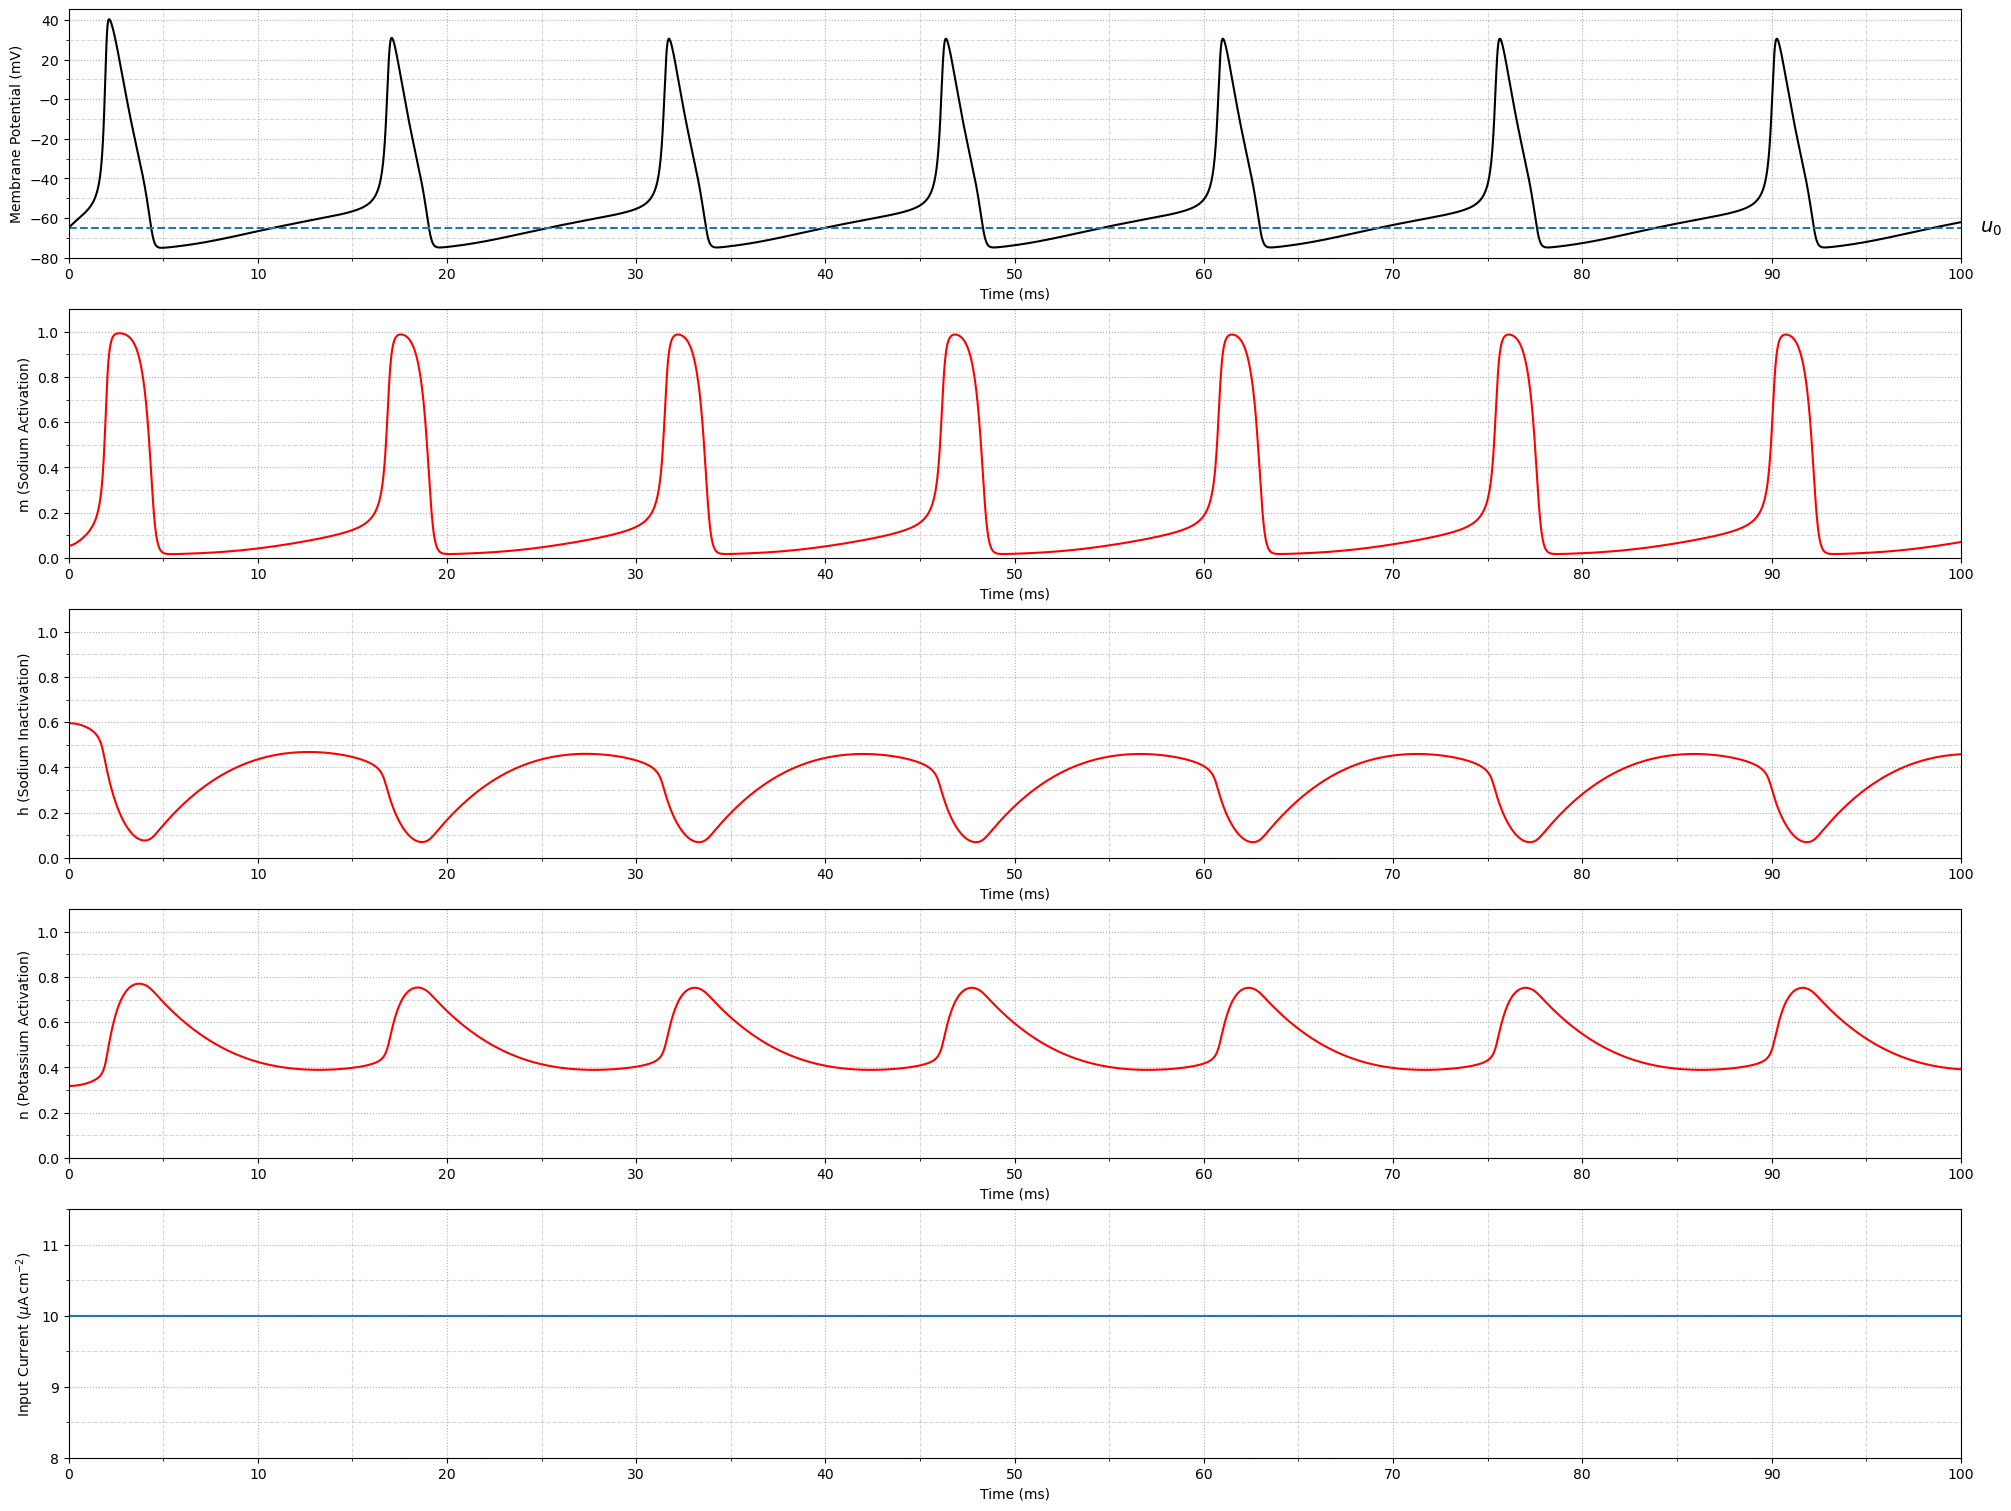

In [9]:
# Extra Parameter
I0 =10  # μA/cm^2

def I_t_step(t,I0=I0):
    """Cosntant Current. A different implementation is done later"""
    return np.full_like(t, I0, dtype=float)

I_step_array = I_t_step(t_array)

sol = solver(I_t_step)
plotter(I_step_array,sol)

**2. periodic square-wave current:**

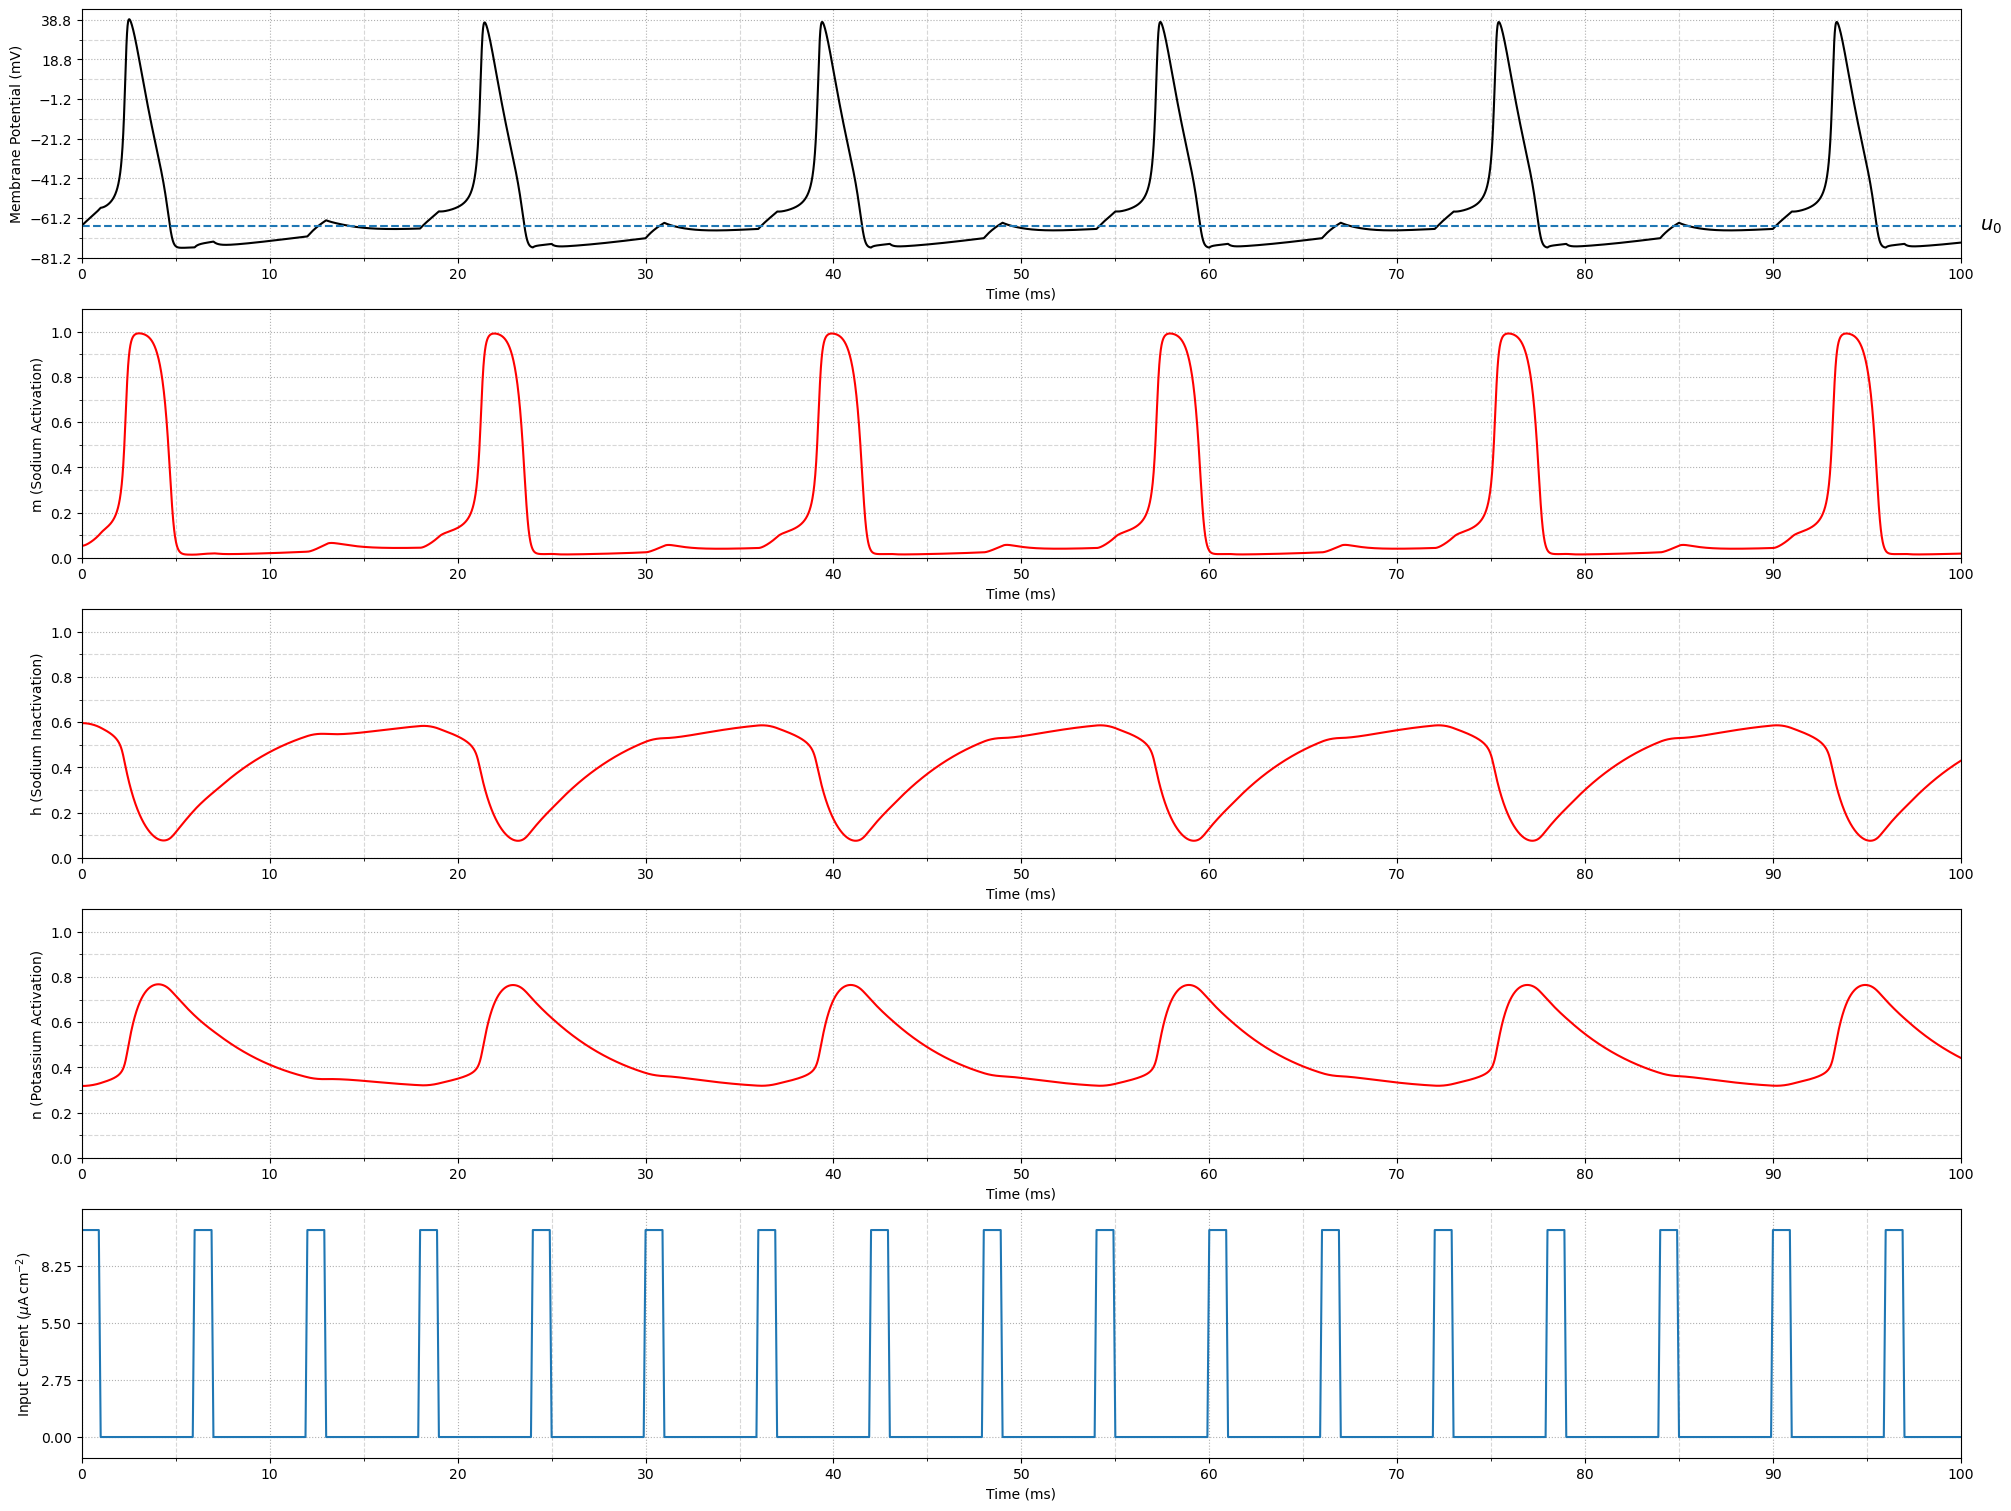

In [10]:
# extra parameters:
I0 = 10  # μA/cm^2
T_sq_on = 1 # ms
T_sq_off = 5 # ms

def I_t_square_wave(t_array , T_sq_on=T_sq_on ,T_sq_off=T_sq_off,time_res = time_res, I0=I0):
    """Square wave with T_sq_on as the time for the current to be on and T_sq_off is I=0 interval."""
    n_T = round(T_sq_on/time_res)
    n_delta = round(T_sq_off/time_res)
    return np.where(np.arange(len(t_array))%(n_T+n_delta)<n_T,I0,0)

I_square = I_t_square_wave(t_array)
I_square_interp = sp.interpolate.make_interp_spline(t_array, I_square, k=0)

sol_sq = solver(I_square_interp)
plotter(I_square,sol_sq)

**3. Sinusoidal Current:**

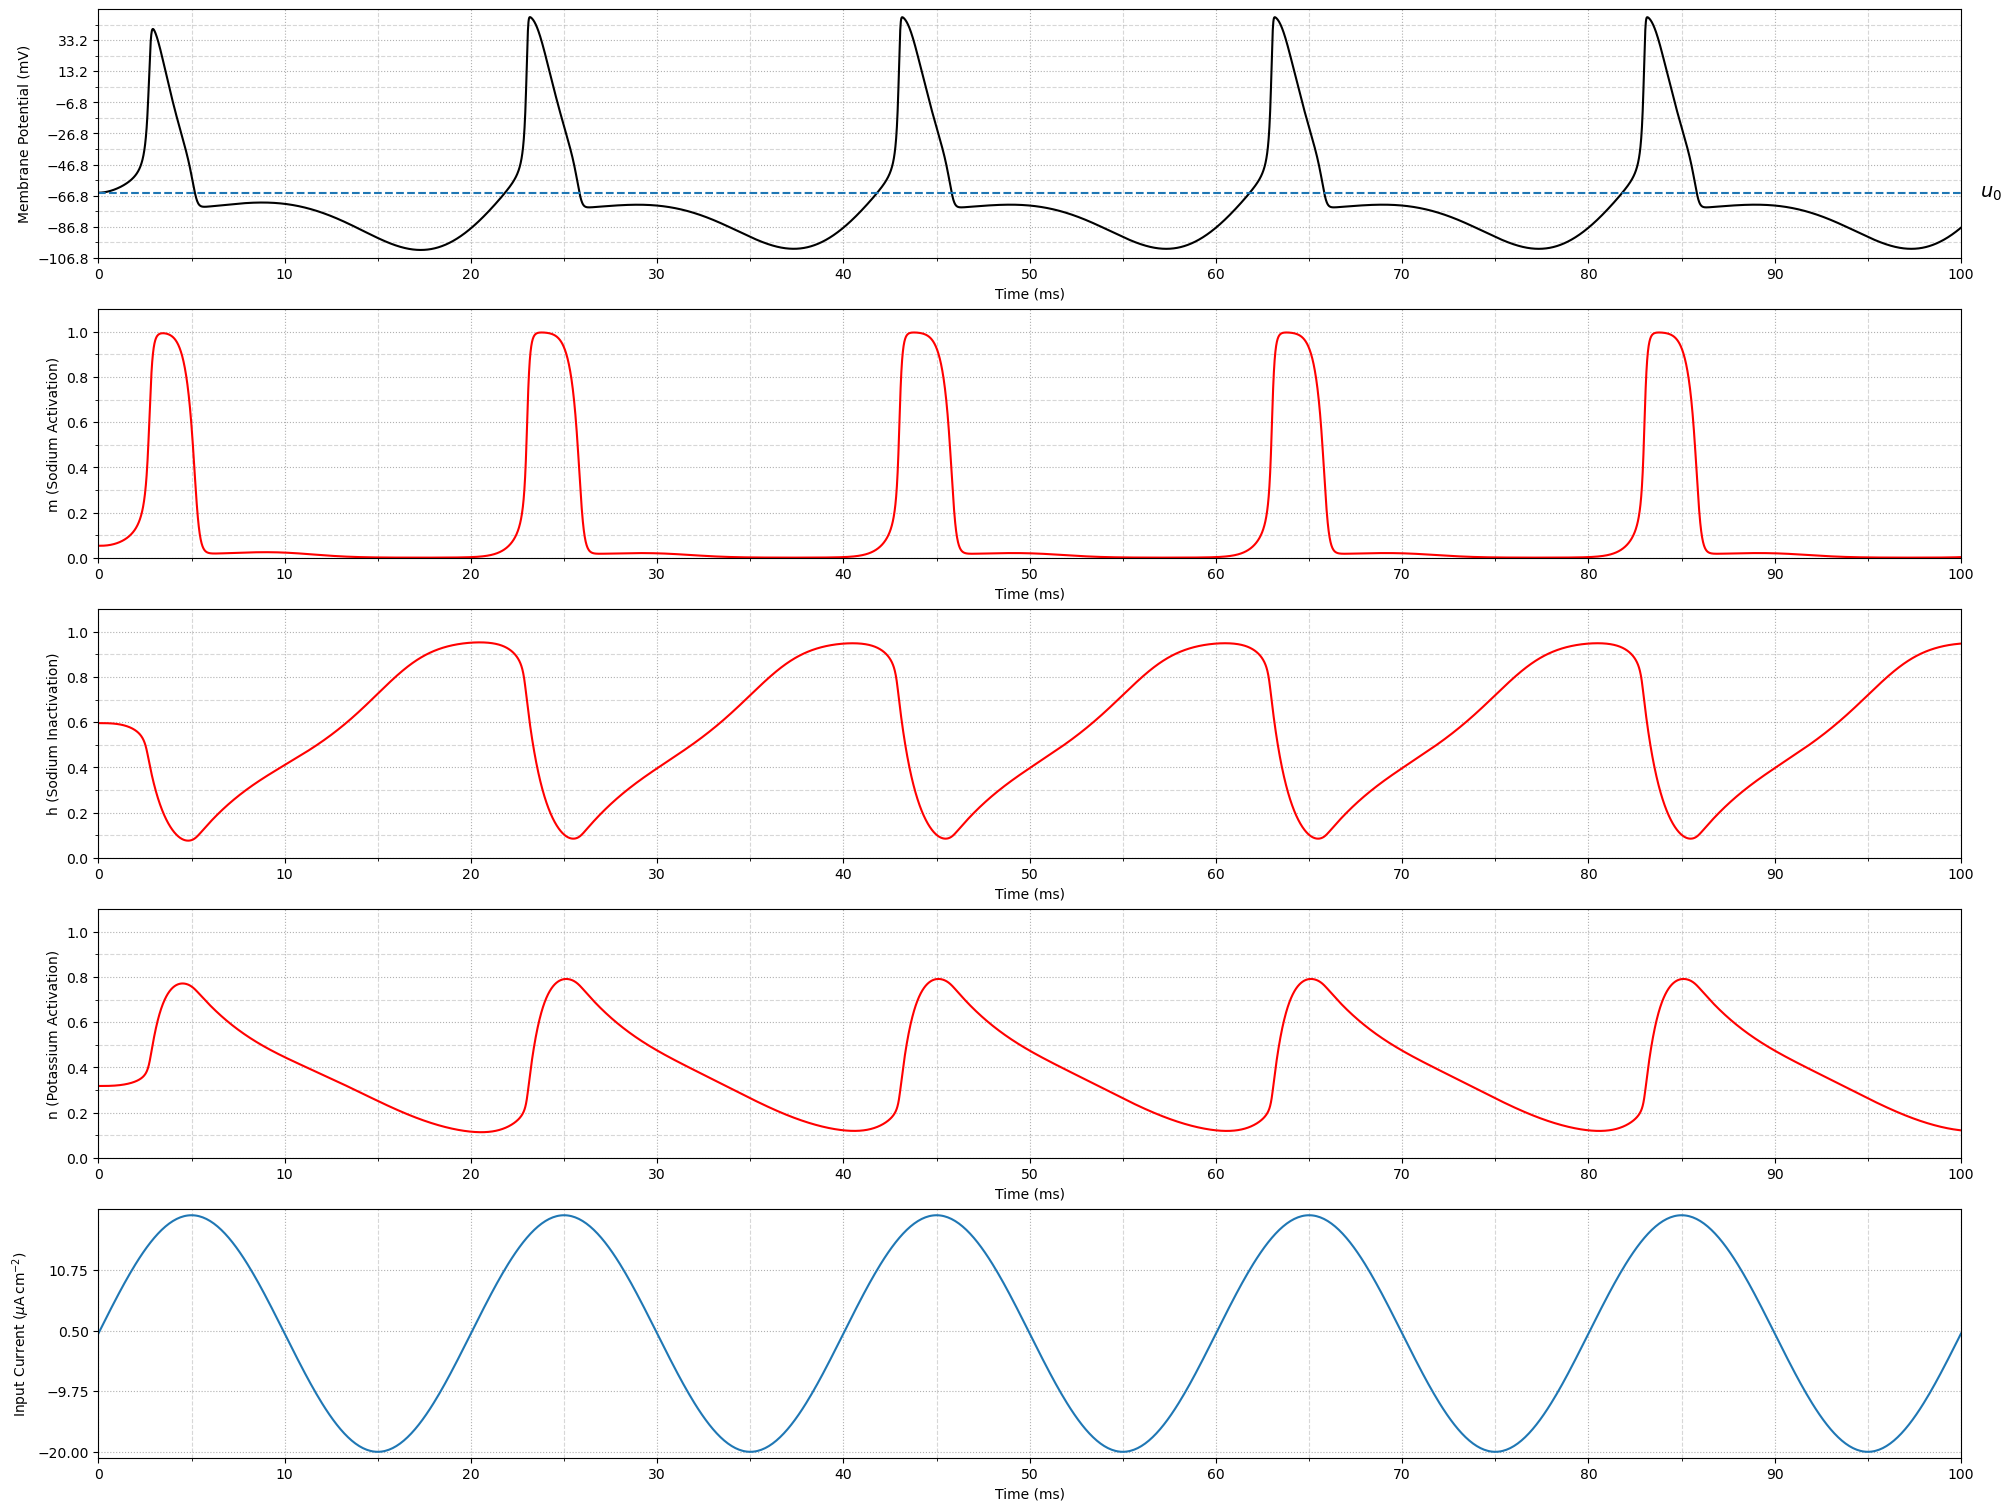

In [11]:
# Extra Parameters (ms to second for t in omega*t is also included)
freq = 50 # Hz
omega = 2*np.pi*freq*1/1000 #Hz
I0 = 20  # μA/cm^2

def I_t_sin(t,I0=I0,omega=omega):
    return I0*np.sin(omega*t)

I_t_sin_array = I_t_sin(t_array)

sol_sin = solver(I_t_sin)
plotter(I_t_sin_array,sol_sin)

**4. Random Noise Current:**

Every 2 ms, a random number is drawn from a Gaussian distribution with zero mean and standard deviation $\sigma = 34 \mu A \mathrm{cm}^{-2}$

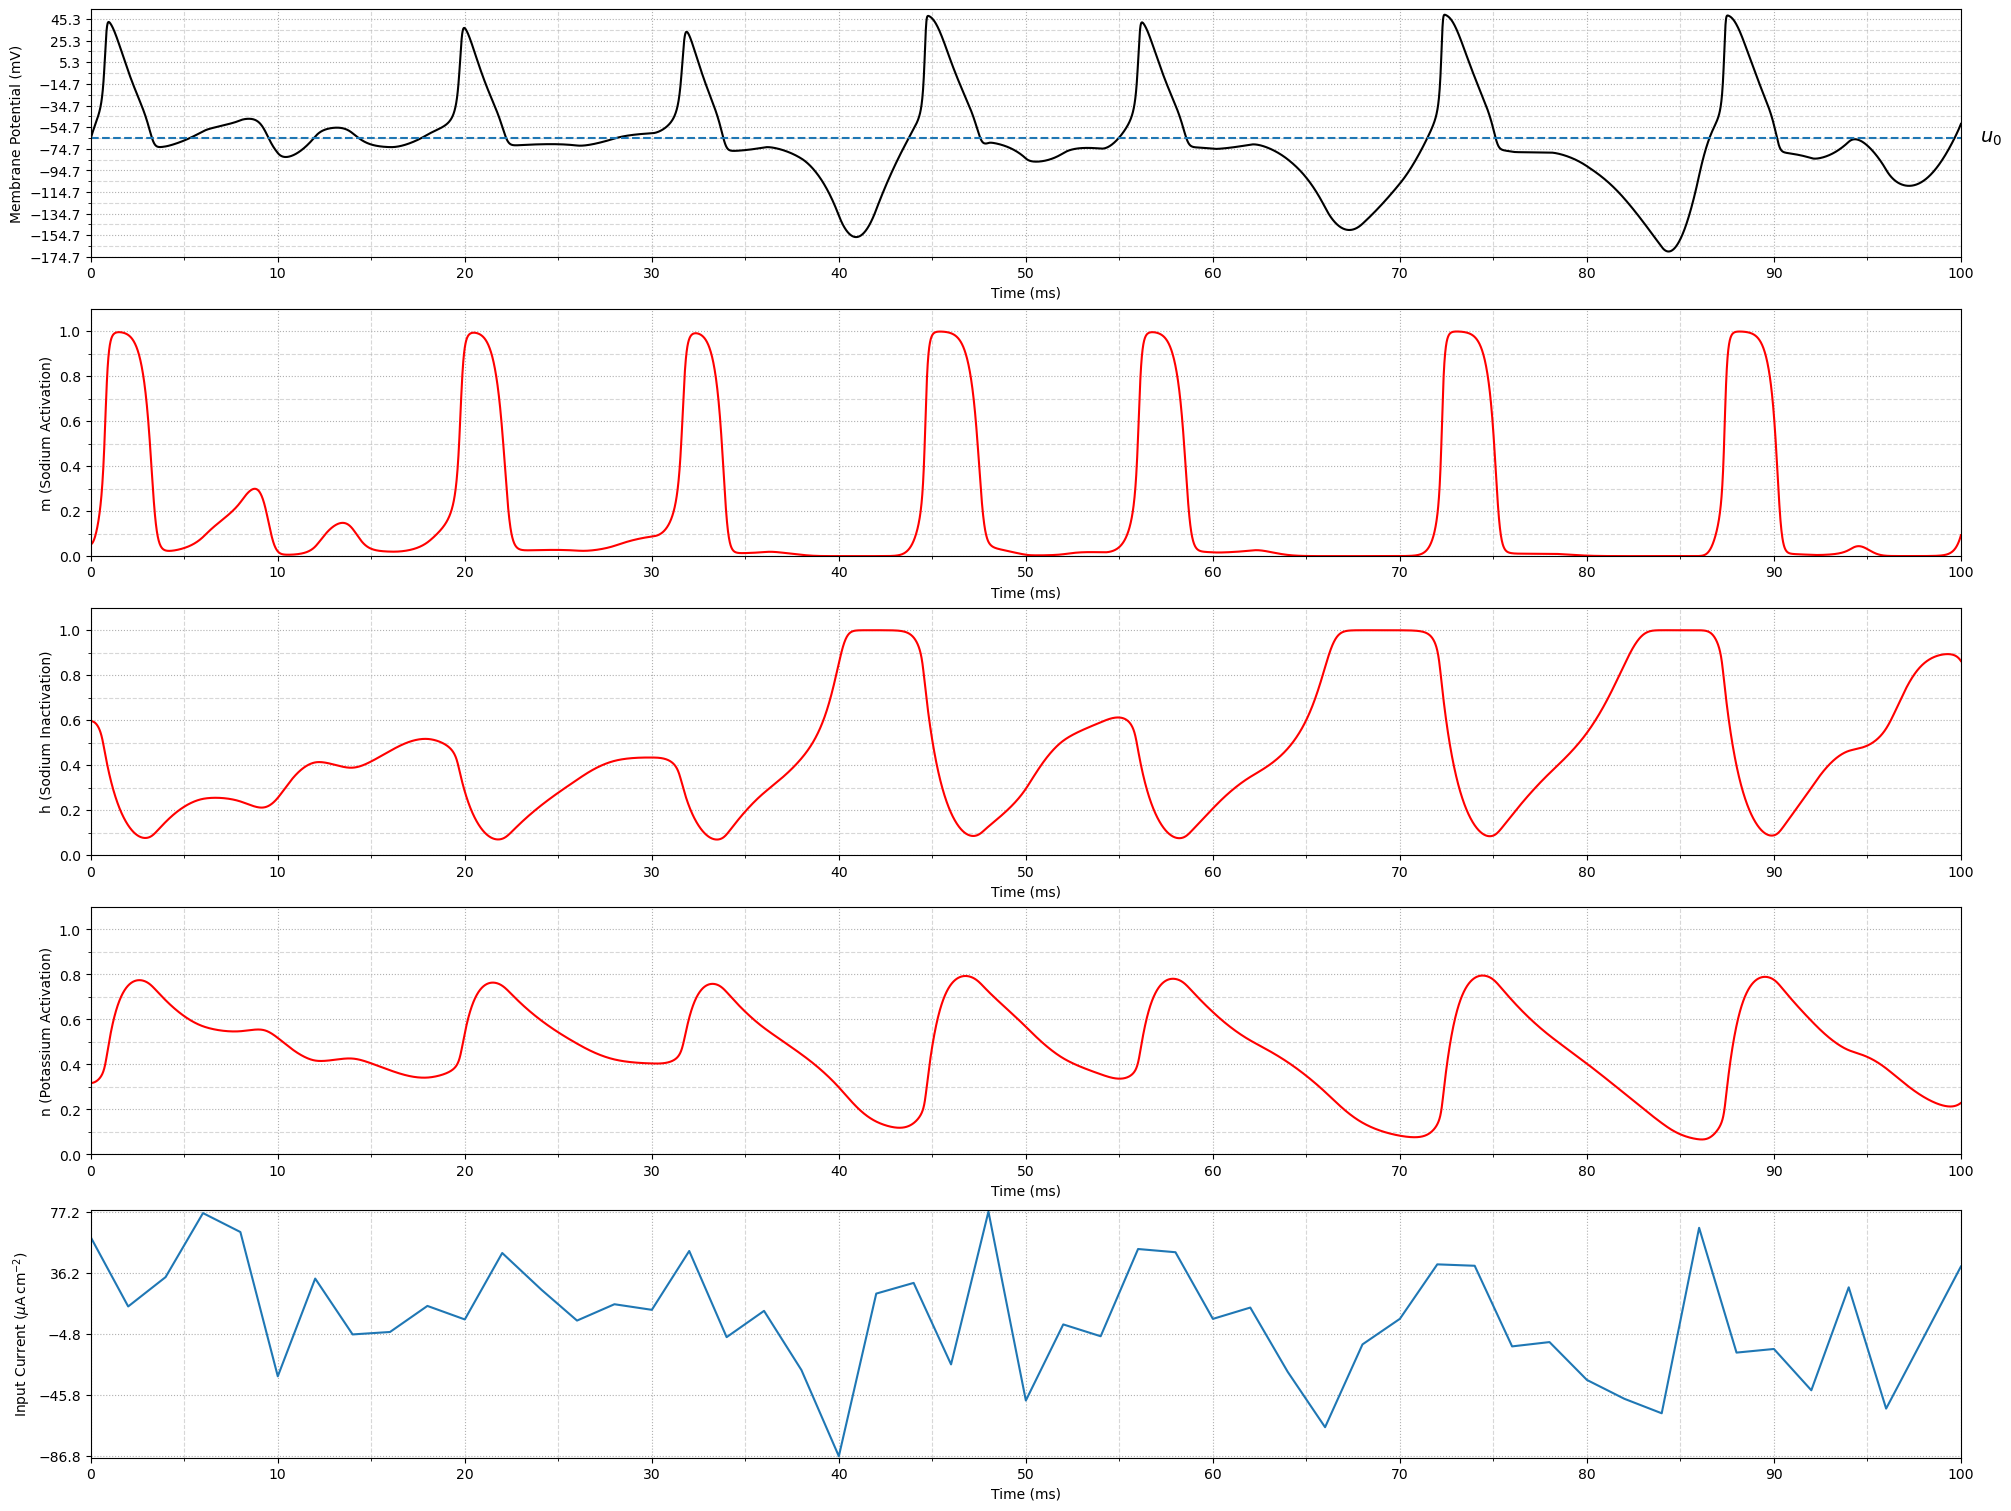

In [12]:
# Random sampling of the input current according to a Gaussian distribution:
np.random.seed(0) # For reproduciblity
delta_t = 2 # ms
sample_num = int(simulation_time/delta_t)
mu, sigma = 0, 34 # mean and standard deviation, respectively [μA/cm^2]

def Gaussian_noise(mu, sigma, sample_num):
    return np.random.normal(mu, sigma, sample_num)

new_t_array = np.arange(t0,simulation_time,delta_t)
I_t_noise_array = Gaussian_noise(mu, sigma, sample_num)
I_noise_interp = sp.interpolate.make_interp_spline(new_t_array, I_t_noise_array, k=1)


sol = solver(I_noise_interp)
plotter(I_noise_interp(t_array),sol)

**f–I Curve**

We can find the gain function by sweeping the input (constant) current from 0 to 50  $\mu A/cm^2$ and plot the firing frequency vs $I_0$.  
**Note:** We will use numba to increase the speed of function calls by the odeint solver.

In [13]:
from scipy.integrate import odeint
from numba import njit

@njit
def alpha_n(u):
    return 0.01*(u+55)/(1-np.exp(-(u+55)/10))
@njit
def alpha_m(u):
    return 0.1*(u+40)/(1-np.exp(-(u+40)/10))
@njit
def alpha_h(u):
    return 0.07*np.exp(-(u+65)/20)
@njit
def beta_n(u):
    return 0.125*np.exp(-(u+65)/80)
@njit
def beta_m(u):
    return 4*np.exp(-(u+65)/18)
@njit
def beta_h(u):
    return 1/(np.exp(-(u+35)/10)+1)

@njit
def func(vec, t , I):
    """constant curent.
    """

    du_dt = 1/C*(I - (
                        g_Na*vec[1]**3*vec[2]*(vec[0]-E_Na) +\
                        g_K*vec[3]**4*(vec[0]-E_K)  +\
                        g_L*(vec[0]-E_L)
                     )
                )
    
    dm_dt = alpha_m(vec[0])*(1-vec[1])-beta_m(vec[0])*vec[1]
    dh_dt = alpha_h(vec[0])*(1-vec[2])-beta_h(vec[0])*vec[2]
    dn_dt = alpha_n(vec[0])*(1-vec[3])-beta_n(vec[0])*vec[3]

    return [du_dt,dm_dt,dh_dt,dn_dt]

extended_interval = np.arange(0,1100,time_res) # Simulating the neuron for 1.1s
vec0 = [u0,m0,h0,n0]
I_range = np.arange(0,50,0.1) # Currents we will sweep the model for.
response = []
for i in I_range:
    response.append(odeint(func, vec0, extended_interval, args=(i,))) # odeint proved to be faster than solve_ivp


We will ignore the first $100ms$ to ensure the system has sufficiently settled into its periodic cycle and to remove transient spiking behaviour. Then, **freqeuncy VS current** is plotted with the $1Hz$ frequency resolution. For this purpose we have converted the membrane response to $\pm 1$ according to their signs and then searched it to find the number of instances at which voltage crosses $0mV$ (from negative to positive).

In [14]:
frequencies = []
for res in response:
    last_1000_ms_responses = res.T[0][100:] # Keeping only the membrane response
    frequencies.append((sum(np.diff(np.sign(last_1000_ms_responses)) == 2)))

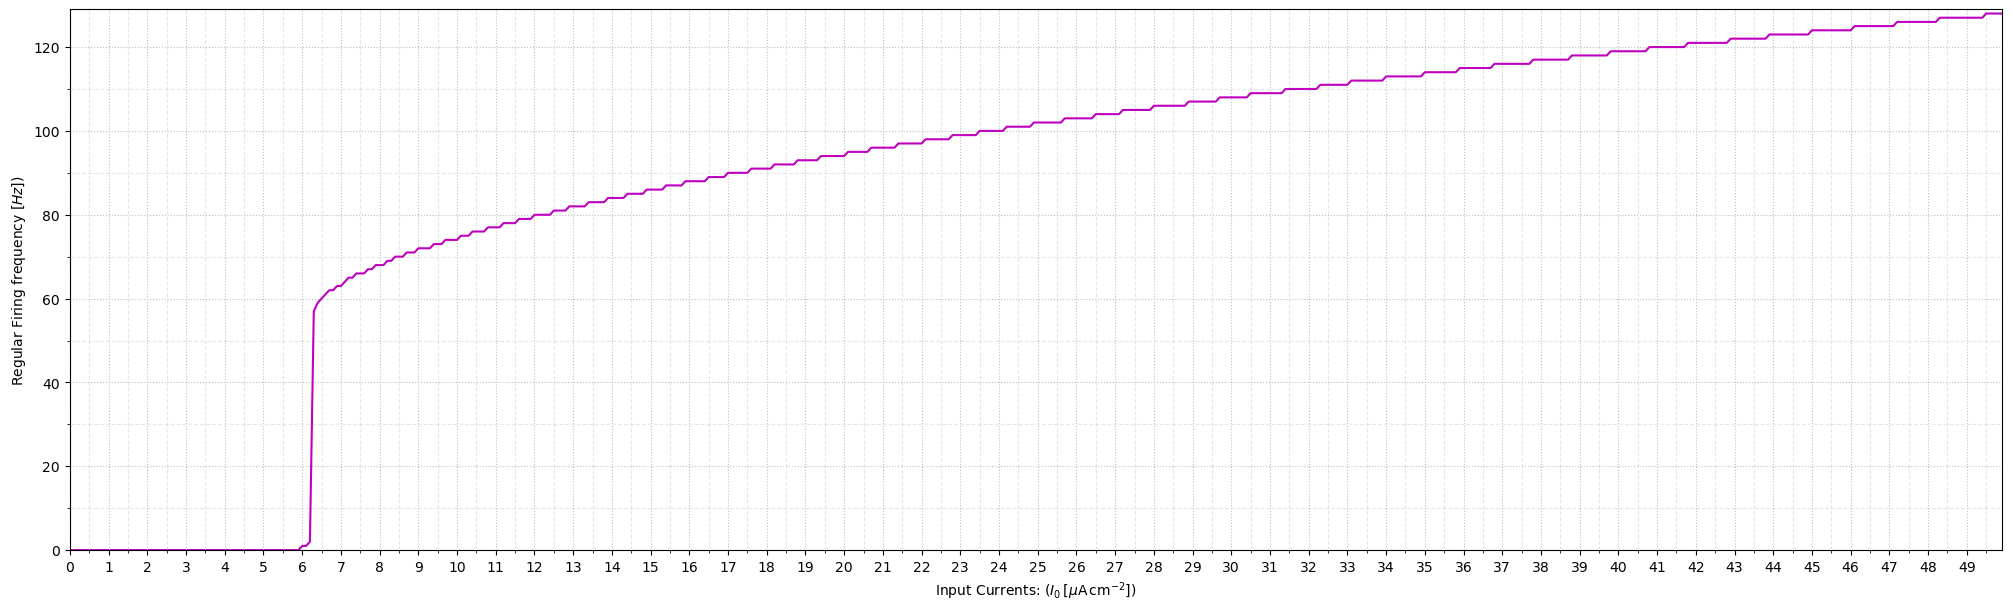

In [15]:
plt.figure(figsize=(20, 6), layout='constrained')

plt.plot(I_range,frequencies,"m-")

x_freq_major_ticks = I_range[::10]
x_freq_minor_ticks = I_range[::5]
y_current_major_ticks = np.arange(min(frequencies), max(frequencies)+1, 20)
y_current_minor_ticks = np.arange(min(frequencies), max(frequencies)+1, 10)

plt.xlim(0,max(I_range))
plt.ylim(0,max(frequencies)+1)
plt.xticks(x_freq_major_ticks)
plt.xticks(x_freq_minor_ticks, minor=True)
plt.yticks(y_current_major_ticks)
plt.yticks(y_current_minor_ticks, minor=True)

plt.grid(which='minor', alpha=0.3,linestyle='--')
plt.grid(which='major', alpha=0.8,linestyle=':')

plt.xlabel(r'Input Currents: ($I_0 \,[\mu\mathrm{A}\,\mathrm{cm}^{-2}]$)')
plt.ylabel(r'Regular Firing frequency $[Hz]$)')

plt.show()

The jump at $I_0=6.3 \, [\mu\mathrm{A}\,\mathrm{cm}^{-2}]$  indicates the expected Type II behaviour of the Hodgkin–Huxley model.

## References

The model and equations in this notebook are from Chapter 2 of:

> NEURONAL DYNAMICS: From Single Neurons to Networks and Models of Cognition
* by Wulfram Gerstner, Werner M. Kistler, Richard Naud, and Liam Paninski.